In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dropout, Input, Dense,GlobalAveragePooling2D,BatchNormalization

In [10]:
def read_data(data_dir):
    img_paths=[]
    labels=[]
    
    for folder in os.listdir(data_dir):
        folder_path=os.path.join(data_dir,folder)
        for img_path in os.listdir(folder_path):
            imgpath=os.path.join(folder_path,img_path)
            img_paths.append(imgpath)
            labels.append(folder)
    df=pd.DataFrame({'img_path':img_paths,'labels':labels}) 
    
    return df     

In [11]:
train_data=read_data("chest_xray_data/test")
test_data=read_data("chest_xray_data/test")
valid_data=read_data("chest_xray_data/val/")

In [12]:
train_data

,img_path,labels
0,chest_xray_data/test/NORMAL/IM-0001-0001.jpeg,NORMAL
1,chest_xray_data/test/NORMAL/IM-0003-0001.jpeg,NORMAL
2,chest_xray_data/test/NORMAL/IM-0005-0001.jpeg,NORMAL
3,chest_xray_data/test/NORMAL/IM-0006-0001.jpeg,NORMAL
4,chest_xray_data/test/NORMAL/IM-0007-0001.jpeg,NORMAL
...,...,...
619,chest_xray_data/test/PNEUMONIA/person96_bacter...,PNEUMONIA
620,chest_xray_data/test/PNEUMONIA/person96_bacter...,PNEUMONIA
621,chest_xray_data/test/PNEUMONIA/person97_bacter...,PNEUMONIA
622,chest_xray_data/test/PNEUMONIA/person99_bacter...,PNEUMONIA


In [13]:
test_data

,img_path,labels
0,chest_xray_data/test/NORMAL/IM-0001-0001.jpeg,NORMAL
1,chest_xray_data/test/NORMAL/IM-0003-0001.jpeg,NORMAL
2,chest_xray_data/test/NORMAL/IM-0005-0001.jpeg,NORMAL
3,chest_xray_data/test/NORMAL/IM-0006-0001.jpeg,NORMAL
4,chest_xray_data/test/NORMAL/IM-0007-0001.jpeg,NORMAL
...,...,...
619,chest_xray_data/test/PNEUMONIA/person96_bacter...,PNEUMONIA
620,chest_xray_data/test/PNEUMONIA/person96_bacter...,PNEUMONIA
621,chest_xray_data/test/PNEUMONIA/person97_bacter...,PNEUMONIA
622,chest_xray_data/test/PNEUMONIA/person99_bacter...,PNEUMONIA


In [14]:
valid_data

,img_path,labels
0,chest_xray_data/val/NORMAL/NORMAL2-IM-1427-000...,NORMAL
1,chest_xray_data/val/NORMAL/NORMAL2-IM-1430-000...,NORMAL
2,chest_xray_data/val/NORMAL/NORMAL2-IM-1431-000...,NORMAL
3,chest_xray_data/val/NORMAL/NORMAL2-IM-1436-000...,NORMAL
4,chest_xray_data/val/NORMAL/NORMAL2-IM-1437-000...,NORMAL
5,chest_xray_data/val/NORMAL/NORMAL2-IM-1438-000...,NORMAL
6,chest_xray_data/val/NORMAL/NORMAL2-IM-1440-000...,NORMAL
7,chest_xray_data/val/NORMAL/NORMAL2-IM-1442-000...,NORMAL
8,chest_xray_data/val/PNEUMONIA/person1946_bacte...,PNEUMONIA
9,chest_xray_data/val/PNEUMONIA/person1946_bacte...,PNEUMONIA


In [15]:
train_data,valid_data= train_test_split(train_data,test_size=0.2,stratify=train_data['labels'],random_state=42) 

In [16]:
img_height, img_width = 224, 224 

train_datagen = ImageDataGenerator(rescale=1./255,rotation_range=20,zoom_range=0.2,width_shift_range=0.1,height_shift_range=0.1,horizontal_flip=True)
train_generator=train_datagen.flow_from_dataframe(train_data,x_col='img_path',y_col='labels',target_size=(img_height,img_width),class_mode='binary',batch_size=32,shuffle=True)

test_datagen=ImageDataGenerator(rescale=1./255)
valid_generator=test_datagen.flow_from_dataframe(valid_data,x_col='img_path',y_col='labels',target_size=(img_height,img_width),class_mode='binary',batch_size=32,shuffle=False)
test_generator=test_datagen.flow_from_dataframe(test_data,x_col='img_path',y_col='labels',target_size=(img_height,img_width),class_mode='binary',batch_size=32,shuffle=False)

Found 499 validated image filenames belonging to 2 classes.
Found 125 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.


In [17]:
base_model = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    
    Dense(512,activation='relu'),
    Dense(256,activation='relu'),
    Dropout(0.3),
    
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(16,activation='relu'),
    Dropout(0.3),


    Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(1e-3),loss='binary_crossentropy',metrics=['accuracy'])

2025-12-22 21:41:16.899967: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-12-22 21:41:16.902267: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [18]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

history=model.fit(train_generator,validation_data=valid_generator,epochs=25,callbacks=callbacks)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5972 - loss: 0.6919 - val_accuracy: 0.6240 - val_loss: 0.6721 - learning_rate: 0.0010
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 996ms/step - accuracy: 0.5972 - loss: 0.6887 - val_accuracy: 0.6240 - val_loss: 0.6679 - learning_rate: 0.0010
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6192 - loss: 0.6667 - val_accuracy: 0.6240 - val_loss: 0.6672 - learning_rate: 0.0010
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 993ms/step - accuracy: 0.6253 - loss: 0.6697 - val_accuracy: 0.6240 - val_loss: 0.6679 - learning_rate: 0.0010
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1000ms/step - accuracy: 0.6152 - loss: 0.6713 - val_accuracy: 0.6240 - val_loss: 0.6728 - learning_rate: 0.0010
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 997ms/step - accuracy: 0.6132 - loss: 0.6758 - val_accuracy: 0.6240 - val_loss: 0.6641 - learning_rate: 0.0010
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 999ms/step - accuracy: 0.6253 - loss: 0.6533 

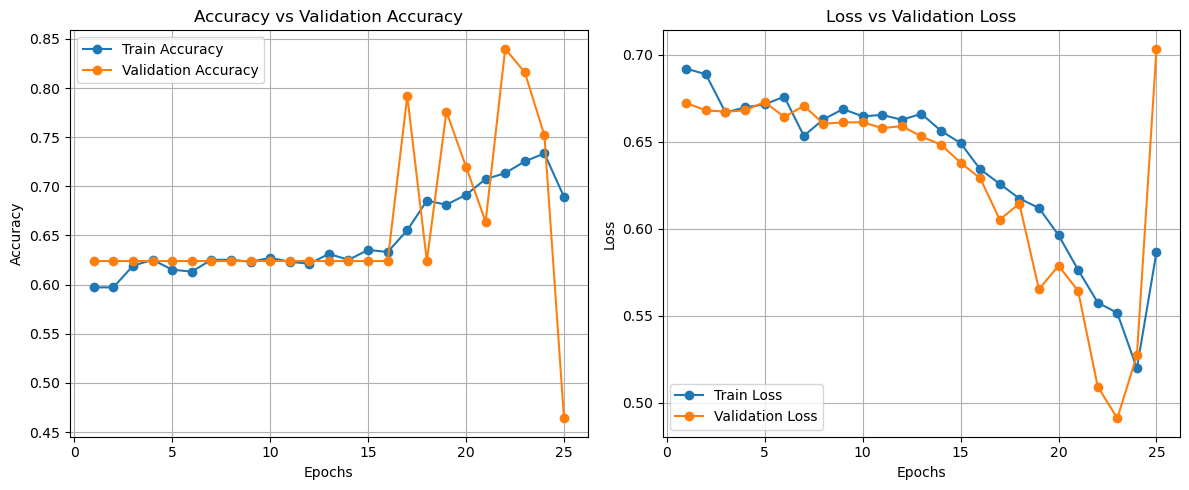

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, marker='o')
plt.plot(epochs, val_acc, marker='o')
plt.title('Accuracy vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(epochs, loss, marker='o')
plt.plot(epochs, val_loss, marker='o')
plt.title('Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
loss_test, accuracy_test = model.evaluate(test_generator)
print("Test Loss:", loss_test)
print("Test Accuracy:", accuracy_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 770ms/step - accuracy: 0.7933 - loss: 0.4886
Test Loss: 0.48856690526008606
Test Accuracy: 0.7932692170143127
